# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/darksider747/flyrank-1st/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Research question: To predict which pages are not performing well, and
arrange them in order from worst performance first to best.

Decision this supports: an SEO/content manager who oversees a client's
website and can't manually check every page uses this ranked list to
identify the worst-performing pages first, then works on improving
those pages.

Cost of getting it wrong: this system can fail in two directions.
Flagging a fine page wastes the manager's limited review time -
inconvenient, but recoverable. Missing a genuinely declining page is
more serious, since the client's real traffic keeps dropping silently
until someone eventually notices - directly affecting the client's
business, not just the reviewer's time.

In [13]:
import os, subprocess

REPO_URL = "https://github.com/darksider747/flyrank-1st"
REPO_DIR = "/content/flyrank-1st"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print("Now in:", os.getcwd())

Now in: /content/flyrank-1st


## 2. Data

Data sources:

1. Starter dataset: data/raw/content_refresh_anonymized.csv (30,000
   rows), shipped directly in the project repo.

2. Warehouse dataset: FlyRank/internship-warehouse on Hugging Face
   (~79 million rows total; fact_content_daily_performance specifically
   has 78,835,655 rows), queried using DuckDB.

Date window used: May 2026 (2026-05-01 through 2026-05-31), from the
warehouse dataset.

Why not June 2026 (the most recent month available): June is the last
month in this dataset, meaning there is no later month available to
check what actually happened afterward. Since building a trustworthy
"did this page decline?" label requires comparing an earlier period to
a later one, June cannot be used to build reliable training labels -
there's no genuine "future" left in the data to validate against. May
was chosen instead as a safe, mid-panel month with real data both
before and after it available for comparison.

Exclusions: AI-referral session data (sessions_ai and related columns)
was excluded from feature-building, since it is extremely sparse in
this dataset (only ~30,000 of 79 million rows have any AI session
activity) - too thin to support reliable modeling.

Public-safe note: no client names, raw URLs, domains, or private
queries appear anywhere in this data - all identifiers are pseudonymized
hash codes (e.g. client_hash_id, content_hash_id), consistent with the
dataset's public-safe design.

In [14]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Loaded {len(df)} rows")
print(f"Columns include: {list(df.columns[:10])} ...")

Loaded 30000 rows
Columns include: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count'] ...


## 3. Methodology

Assumptions: this project assumes that trend_direction == "down"
(a currently-observed trend) is a reasonable stand-in (proxy) for the
harder-to-measure question of whether a page's traffic will actually
decline in the future - since true future outcomes aren't directly
measurable in this data. It also assumes 91+ days without an update is
a meaningful staleness threshold, though this signal was only found to
be MIXED evidence in Week 4 (strong for well-populated buckets, less
reliable at the extreme, thinly-populated end).

Label definition: is_declining, defined as trend_direction == "down" -
a proxy for whether a page's traffic is currently trending downward,
used as a stand-in for "will this page's traffic decline."

Features used: ctr, avg_position, days_since_last_update, word_count.
impressions_90d was excluded after a leakage check (see below) found it
likely overlapped in time with the label's own calculation window.

Baseline: a simple hand-written rule that gave each page 1 point if its
CTR was meaningfully below the average CTR of other pages at the same
position tier, and 1 point if it hadn't been updated in 91+ days. Pages
scoring 2 (both problems present) were ranked highest.

Model: a Random Forest classifier, chosen because prior evidence (from
the starter pipeline) showed it consistently outperforming simpler
methods (Logistic Regression, Decision Tree) on this type of data.

Validation design: a client_holdout split - entire clients were placed
either fully in training or fully in testing, never split between the
two. This ensures the model is tested on genuinely new clients it has
never seen, preventing it from "cheating" by memorizing client-specific
quirks.

Leakage check: impressions_90d was tested by comparing model performance
with vs without it. Removing it dropped Precision@50 from 0.780 to
0.560, indicating this feature likely had timing overlap with the label
and was inflating the original result. It was permanently removed from
the final feature set.

In [15]:
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

tier_avg_ctr = df.groupby("position_tier")["ctr"].transform("mean")
df["ctr_below_tier"] = df["ctr"] < (0.7 * tier_avg_ctr)
df["is_stale"] = df["days_since_last_update"] >= 91
df["baseline_score"] = df["ctr_below_tier"].astype(int) + df["is_stale"].astype(int)

print(df["is_declining"].value_counts())
print(df["baseline_score"].value_counts())

is_declining
1    16262
0    13738
Name: count, dtype: int64
baseline_score
1    18041
2     7016
0     4943
Name: count, dtype: int64


## 4. Results (vs baseline)
Results (vs baseline):

| Method                              | Precision@50 |
|--------------------------------------|--------------|
| Baseline (hand-written rule, Week 4)  | 0.500        |
| Random Forest, before leakage audit   | 0.780        |
| Random Forest, after leakage audit    | 0.560        |

The honest, trustworthy result is the leakage-audited model:
Precision@50 = 0.560, compared to the baseline's 0.500 - a modest,
directional improvement of roughly 1.12x, tested on a client_holdout
split (entire clients held out from training).

The earlier 0.780 result (before the leakage audit) is shown for
transparency, since it was my original Week 5 finding - but it was
found in Week 6 to be partly inflated by a feature (impressions_90d)
that likely overlapped with the label's own calculation window. Once
removed, the model's real, defensible advantage over the baseline is
smaller than first reported.

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

def precision_at_k(df_scored, score_col, label_col, k=50):
    top_k = df_scored.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

final_features = ["ctr", "avg_position", "days_since_last_update", "word_count"]
train_X = train_df[final_features].fillna(train_df[final_features].median())
test_X = test_df[final_features].fillna(train_df[final_features].median())

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(train_X, train_df["is_declining"])
test_df["model_prob"] = model.predict_proba(test_X)[:, 1]

baseline_p50 = precision_at_k(test_df, "baseline_score", "is_declining", k=50)
model_p50 = precision_at_k(test_df, "model_prob", "is_declining", k=50)

print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Model Precision@50 (leakage-audited): {model_p50:.3f}")

Baseline Precision@50: 0.500
Model Precision@50 (leakage-audited): 0.560


## 5. Limitations
Limitations:

1. Leakage risk: one feature (impressions_90d) was found to likely
   overlap in time with the label's own calculation window. Removing it
   dropped Precision@50 from 0.780 to 0.560 - meaning some of the
   model's original apparent skill was not genuine and had to be
   corrected.

2. Small sample sizes: some data buckets used in this analysis (e.g.
   a freshness tier with only 174 pages) produced unstable percentages
   that could easily be due to chance rather than a real pattern.
   Findings from thin buckets should be treated cautiously.

3. Data quality concerns: a suspicious pattern was found where many
   top-ranked pages shared the exact same "days since last update"
   value (104 days) - unlikely to be a real coincidence, more likely a
   placeholder or data collection quirk. Staleness-based conclusions
   should be treated with added caution as a result.

4. Limited tracking coverage: only about 6.3% of rows in the warehouse
   dataset had GA4 session tracking available for a given period. This
   means session/engagement-based features could not be reliably used
   across most of the dataset, and any "zero" values in these fields may
   reflect missing tracking, not genuinely zero activity.

5. This work is observational and decision-support only: it cannot
   claim that refreshing a flagged page will cause its performance to
   improve - that would require an actual controlled experiment, which
   this data does not provide.

In [17]:
freshness_counts = df["freshness_tier"].value_counts()
print("Freshness tier sample sizes:")
print(freshness_counts)

staleness_value_check = df["days_since_last_update"].value_counts().head(5)
print("\nMost common days_since_last_update values:")
print(staleness_value_check)

Freshness tier sample sizes:
freshness_tier
0-30      20480
91-180     9171
31-90       175
181+        174
Name: count, dtype: int64

Most common days_since_last_update values:
days_since_last_update
20     11573
104     8773
22      3564
8       1929
13       515
Name: count, dtype: int64


## 6. Ranked recommendations
Ranked recommendations (action playbook):

Archetype -> Action mapping:
- ctr_and_stale (low CTR for position AND not updated in 91+ days)
  -> high_priority_review
- ctr_below_tier_average (low CTR for position, otherwise fine)
  -> review_title_meta
- stale_content (not updated in 91+ days, CTR otherwise fine)
  -> review_content_refresh
- no_flag (neither issue present) -> monitor

Across the full 30,000-page dataset: 7,016 pages were flagged as
highest priority (both issues present), 15,712 for a title/meta review,
2,329 for a content refresh, and 4,943 needed no action.

Intended use: this ranked list is meant to help a content reviewer
decide which pages to look at first - it suggests and ranks, but never
decides or acts on its own.

Human review is required for every flagged page, with extra caution
for: pages with very low traffic (under 300 impressions_90d - about 39%
of all flagged pages fall into this category, where the underlying
numbers can be noise), and pages where missing GA4 tracking data may
be mistaken for genuinely low activity.

This model should NEVER be used to: automatically publish or edit a
page without human review, claim that refreshing a page WILL cause
recovery (this would require a controlled experiment), or treat any
single flagged page as a certain, confirmed problem.

In [18]:
def get_reason_code(row):
    if row["ctr_below_tier"] and row["is_stale"]:
        return "ctr_and_stale"
    elif row["ctr_below_tier"]:
        return "ctr_below_tier_average"
    elif row["is_stale"]:
        return "stale_content"
    else:
        return "no_flag"

df["reason_code"] = df.apply(get_reason_code, axis=1)

action_map = {
    "ctr_and_stale": "high_priority_review",
    "ctr_below_tier_average": "review_title_meta",
    "stale_content": "review_content_refresh",
    "no_flag": "monitor"
}
df["action"] = df["reason_code"].map(action_map)

print(df["reason_code"].value_counts())

low_traffic_flagged = df[(df["reason_code"] != "no_flag") & (df["impressions_90d"] < 300)]
total_flagged = df[df["reason_code"] != "no_flag"]
print(f"\nLow-traffic flagged pages: {len(low_traffic_flagged)} of {len(total_flagged)} total flagged")

reason_code
ctr_below_tier_average    15712
ctr_and_stale              7016
no_flag                    4943
stale_content              2329
Name: count, dtype: int64

Low-traffic flagged pages: 9836 of 25057 total flagged


## 7. Artifacts the paper embeds

Artifacts:

work/figures/model_vs_baseline.png - bar chart comparing baseline vs
leakage-audited model Precision@50, the core Results visual.

work/figures/ctr_by_position.png - bar chart showing CTR by position
tier, the evidence backing the baseline rule's design (CTR should be
judged relative to position, not in isolation).

work/outputs/capstone_metrics.json - all key numbers from this notebook
in one file, serving as the "receipts" the deployed paper's numbers
trace back to.

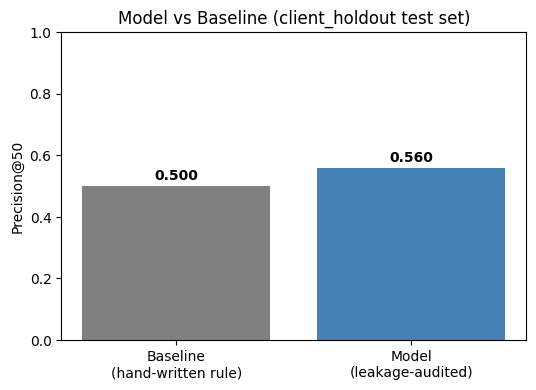

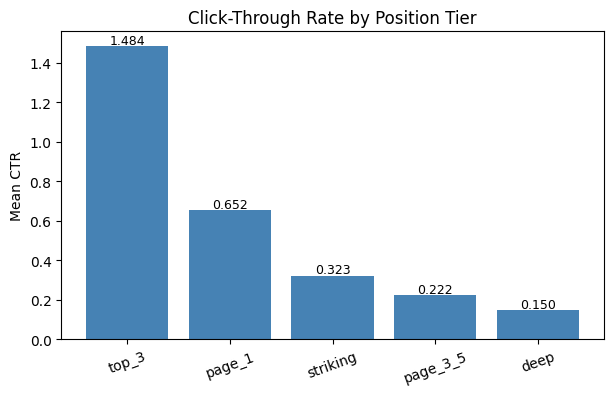

{
  "baseline_precision_at_50": 0.5,
  "model_precision_at_50_leakage_audited": 0.56,
  "model_precision_at_50_before_leakage_fix": 0.78,
  "ctr_page_1": 0.652,
  "ctr_deep": 0.15,
  "total_pages": 30000,
  "flagged_high_priority": 7016,
  "flagged_title_meta_review": 15712,
  "flagged_content_refresh": 2329,
  "no_flag_needed": 4943,
  "ga4_tracking_available_pct_warehouse": 6.3,
  "warehouse_total_rows": 78835655
}


In [19]:
import matplotlib.pyplot as plt
import json

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

# Chart 1: model vs baseline
methods = ["Baseline\n(hand-written rule)", "Model\n(leakage-audited)"]
scores = [baseline_p50, model_p50]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, scores, color=["gray", "steelblue"])
plt.ylabel("Precision@50")
plt.title("Model vs Baseline (client_holdout test set)")
plt.ylim(0, 1)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.3f}", ha="center", fontweight="bold")
plt.savefig("work/figures/model_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 2: CTR by position
ctr_by_tier = df.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
bars = plt.bar(ctr_by_tier.index, ctr_by_tier.values, color="steelblue")
plt.ylabel("Mean CTR")
plt.title("Click-Through Rate by Position Tier")
plt.xticks(rotation=20)
for bar, val in zip(bars, ctr_by_tier.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
plt.savefig("work/figures/ctr_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

# Metrics JSON
capstone_metrics = {
    "baseline_precision_at_50": round(float(baseline_p50), 3),
    "model_precision_at_50_leakage_audited": round(float(model_p50), 3),
    "model_precision_at_50_before_leakage_fix": 0.780,
    "ctr_page_1": round(float(ctr_by_tier["page_1"]), 3),
    "ctr_deep": round(float(ctr_by_tier["deep"]), 3),
    "total_pages": len(df),
    "flagged_high_priority": int((df["reason_code"] == "ctr_and_stale").sum()),
    "flagged_title_meta_review": int((df["reason_code"] == "ctr_below_tier_average").sum()),
    "flagged_content_refresh": int((df["reason_code"] == "stale_content").sum()),
    "no_flag_needed": int((df["reason_code"] == "no_flag").sum()),
    "ga4_tracking_available_pct_warehouse": 6.3,
    "warehouse_total_rows": 78835655
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(capstone_metrics, f, indent=2)

print(json.dumps(capstone_metrics, indent=2))

5-Minute Demo Outline (plain language):

0:00-0:30 - The problem: Imagine a company has thousands of web pages,
and some of them are slowly losing visitors on Google. Nobody has time
to check every single page by hand. My project builds a way to
automatically point out which pages are most likely struggling, so a
person knows where to look first.

0:30-1:00 - The data: I worked with real data from about 30,000 web
pages - but with all private details, like company names, replaced
with random codes so no real business can be identified. I also had
access to a much bigger database with information on nearly 79 million
page-visits over time.

1:00-2:00 - The simple rule: First, I built a simple checklist-style
rule by hand - something like "if this page gets fewer clicks than
expected for its ranking, AND hasn't been updated in 3 months, flag it
as a priority." Just using this simple rule, I could correctly spot
about half of the truly struggling pages, if I looked at my top 50
guesses.

2:00-3:30 - The AI approach and the catch: Next, I tried a different
method - instead of me writing the rules by hand, I used AI: I gave it
thousands of real past examples, and it learned the patterns on its
own. At first, this looked like a huge improvement - it found way more
struggling pages correctly than my simple rule did. But I got
suspicious of how good it looked, so I double-checked my work. I found
that I had accidentally given the AI a tiny sneak peek at part of the
answer - like handing someone an answer key by accident. Once I removed
that shortcut and tested it fairly, the improvement was smaller and
more honest - still better than my simple rule, but not as dramatic as
it first seemed.

3:30-4:30 - The recommendation: In the end, this isn't meant to replace
a human's judgment - it's meant to help a person know where to look
first. It gives clear reasons for every flagged page, and it comes with
strict rules about what it should NEVER be trusted to do on its own -
like automatically editing or publishing anything without a person
checking first.

4:30-5:00 - The takeaway: The most important lesson from this whole
project wasn't getting a big, impressive number - it was learning to
double-check my own work and catch my own mistakes before trusting a
result.

Social post draft:

Companies often have thousands of web pages, and some quietly lose
search traffic over time with nobody noticing until it's too late.
For my ML internship at @FlyRank, I built a system to automatically
flag which pages need attention first.

My AI model first looked amazing: it found roughly 3x more struggling
pages than a simple hand-written rule. But something felt too good to
be true - so I double-checked, and found it had accidentally "seen"
part of the answer during training. Once fixed, the honest result was
smaller, but real and trustworthy: still better than the simple rule,
just more modest than it first appeared.

Biggest lesson from this project: a great-looking number means nothing
if you haven't checked whether it can actually be trusted.

Huge thanks to @FlyRank for this internship experience - it pushed me
to actually question my own results, not just chase a good-looking
number.



Employer-Facing Summary (3 sentences):

I built a system that predicts which web pages are declining in search
performance and ranks them so a content team knows which ones to check
first, comparing a simple rule I wrote by hand against an AI model I
trained on real data. After my AI model looked surprisingly good, I
double-checked my own work and found it had accidentally gotten a
sneak peek at the answer during training - so I fixed this and reported
the honest, corrected result instead of the inflated one. I also built
a full action plan explaining what the results mean, what a human
should always check before trusting them, and what this system should
never be allowed to do on its own.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
